# MGSC 416 — Coffee shop inventory and ordering

## Section 1 — Introduction

This notebook supports an **MGSC 416** semester project on **data-driven operations** for a multi-site coffee business. We use real-world-style transaction data (Maven Roasters) to study **how much to stock** at each location and how demand varies over time.

### Context and motivation

Retail cafes must balance **service level** (having enough product when customers arrive) with **waste and tied-up cash** when prepared or perishable items are not sold the same day. Line-level sales history lets us recover **true baskets** (several products sold in one checkout) and **per-store** patterns, which a simple daily total cannot show.

### What this notebook does

- Load and validate **line-level** transactions from Excel.
- Build **`order_id`** from store + timestamp so lines sold in the same second count as one order.
- Summarise demand and revenue for **each store** and produce figures for the report.
- Later sections (stubs for now) will add calendar features, forecasting, and **optimisation** for order quantities.

### Data source

**[Coffee Shop Sales.xlsx](../Coffee+Shop+Sales/Coffee%20Shop%20Sales.xlsx)** — sheet `Transactions` (timestamps, store, product hierarchy, quantities, and prices).

### Tools

Python **pandas**, **numpy**, **matplotlib**, **seaborn**, and **openpyxl** for reading Excel.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_PATH = PROJECT_ROOT / "Coffee+Shop+Sales" / "Coffee Shop Sales.xlsx"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())

Project root: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\semestral_work_DD
Data path exists: True


---

## Section 2 — Data loading

Load the **Transactions** sheet, inspect shape, dtypes, and missing values.

In [2]:
raw = pd.read_excel(DATA_PATH, sheet_name="Transactions", engine="openpyxl")
print("Shape:", raw.shape)
print(raw.dtypes)
raw.info()
display(raw.head())
missing = raw.isna().sum()
print("Missing per column:")
print(missing[missing > 0] if missing.any() else "None")

Shape: (149116, 11)
transaction_id               int64
transaction_date    datetime64[ns]
transaction_time            object
transaction_qty              int64
store_id                     int64
store_location              object
product_id                   int64
unit_price                 float64
product_category            object
product_type                object
product_detail              object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   transaction_id    149116 non-null  int64         
 1   transaction_date  149116 non-null  datetime64[ns]
 2   transaction_time  149116 non-null  object        
 3   transaction_qty   149116 non-null  int64         
 4   store_id          149116 non-null  int64         
 5   store_location    149116 non-null  object        
 6   product_id        149116 

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


Missing per column:
None


---

## Section 3 — Cleaning and validation (person 1)

Checklist: duplicates → `transaction_id` pattern → datetimes → numeric checks → product hierarchy → stores → **`order_id`** → cost columns → optional export.

In [3]:
df = raw.copy()
n_before = len(df)
dup_mask = df.duplicated(keep=False)
n_dup = dup_mask.sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Full-row duplicates removed: {n_before - len(df)} rows (checked {n_dup} in duplicate groups)")

Full-row duplicates removed: 0 rows (checked 0 in duplicate groups)


In [4]:
tid_counts = df["transaction_id"].value_counts()
print("transaction_id unique:", df["transaction_id"].nunique(), "rows:", len(df))
print("Max rows sharing one transaction_id:", int(tid_counts.max()))
print(
    "Interpretation: if max is 1, each row is its own id — use datetime basket key for orders."
)

transaction_id unique: 149116 rows: 149116
Max rows sharing one transaction_id: 1
Interpretation: if max is 1, each row is its own id — use datetime basket key for orders.


In [5]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])
df["transaction_dt"] = pd.to_datetime(
    df["transaction_date"].dt.strftime("%Y-%m-%d")
    + " "
    + df["transaction_time"].astype(str)
)
df["date"] = df["transaction_dt"].dt.normalize()
df["hour"] = df["transaction_dt"].dt.hour
df["dow"] = df["transaction_dt"].dt.dayofweek
df["month"] = df["transaction_dt"].dt.month
df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_dt,date,hour,dow,month,is_weekend
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,2023-01-01 07:06:11,2023-01-01,7,6,1,1
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:08:56,2023-01-01,7,6,1,1
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,2023-01-01 07:14:04,2023-01-01,7,6,1,1
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm,2023-01-01 07:20:24,2023-01-01,7,6,1,1
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,2023-01-01 07:22:41,2023-01-01,7,6,1,1


In [6]:
bad_qty = df["transaction_qty"] <= 0
bad_price = df["unit_price"] < 0
print("Rows with qty <= 0:", bad_qty.sum())
print("Rows with unit_price < 0:", bad_price.sum())
df = df.loc[~(bad_qty | bad_price)].copy()


Rows with qty <= 0: 0
Rows with unit_price < 0: 0


### Numeric checks, then revenue and cost columns

After dropping invalid quantities and prices, we add **line revenue** and a **per-unit COGS** used later for waste. **Working assumption:** **60% gross margin** on the selling price, so **COGS = 40% of `unit_price`**. If a prepared unit does **not** sell that day, we treat the money at risk as that COGS (**`unsold_loss_per_unit`**), i.e. **0.4 × unit_price** for each unit written off.

You can change `GROSS_MARGIN` below for sensitivity analysis; downstream optimisation should read the same constants.


In [7]:
# Margin assumption for same-day unsold units (inventory write-off)
GROSS_MARGIN = 0.60
COGS_SHARE = 1.0 - GROSS_MARGIN

df["line_revenue"] = df["transaction_qty"] * df["unit_price"]
df["unit_cogs"] = COGS_SHARE * df["unit_price"]
df["unsold_loss_per_unit"] = df["unit_cogs"]

print(f"Gross margin assumption: {GROSS_MARGIN:.0%} of shelf price")
print(f"COGS share (economic loss if one unit is not sold that day): {COGS_SHARE:.0%} of unit_price")


Gross margin assumption: 60% of shelf price
COGS share (economic loss if one unit is not sold that day): 40% of unit_price


In [8]:
for col in ["product_category", "product_type", "product_detail"]:
    df[col] = df[col].fillna("unknown")
n_unknown = (df[["product_category", "product_type", "product_detail"]] == "unknown").any(axis=1).sum()
print("Rows with any unknown product field:", n_unknown)

Rows with any unknown product field: 0


In [9]:
stores = df[["store_id", "store_location"]].drop_duplicates().sort_values("store_id")
display(stores)
assert df["store_id"].nunique() == 3, "Expected three stores"
print("Store check: OK (3 locations).")

,store_id,store_location
105,3,Astoria
0,5,Lower Manhattan
17,8,Hell's Kitchen


Store check: OK (3 locations).


In [10]:
df["order_key"] = (
    df["store_id"].astype(str)
    + "|"
    + df["transaction_dt"].dt.strftime("%Y-%m-%d %H:%M:%S")
)
df["order_id"] = df["order_key"]
lines_per_tid = df.groupby("transaction_id", observed=True).size()
lines_per_order = df.groupby("order_id", observed=True).size()
print("Lines per transaction_id (max):", int(lines_per_tid.max()))
print("Lines per order_id (max):", int(lines_per_order.max()))
print("Multi-line orders:", int((lines_per_order > 1).sum()))

Lines per transaction_id (max): 1
Lines per order_id (max): 7
Multi-line orders: 29260


In [11]:
lines_path = OUTPUTS_DIR / "lines_clean.csv"
df.to_csv(lines_path, index=False)
print("Wrote:", lines_path, "rows:", len(df))

Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\semestral_work_DD\outputs\lines_clean.csv rows: 149116


---

## Section 4 — Order-level dataset

One row per `order_id` with basket size and revenue (for AOV and multi-item behaviour).

In [12]:
order_agg = (
    df.groupby(["order_id", "store_id", "store_location", "date"], observed=True)
    .agg(
        n_lines=("transaction_id", "count"),
        order_qty_total=("transaction_qty", "sum"),
        order_revenue=("line_revenue", "sum"),
    )
    .reset_index()
)
orders_path = OUTPUTS_DIR / "orders_clean.csv"
order_agg.to_csv(orders_path, index=False)
print("Orders:", len(order_agg), "→", orders_path)
order_agg.describe()

Orders: 116790 → C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\semestral_work_DD\outputs\orders_clean.csv


,store_id,date,n_lines,order_qty_total,order_revenue
count,116790.000000,116790,116790.000000,116790.000000,116790.000000
mean,5.342444,2023-04-15 10:08:27.125609984,1.276787,1.836373,5.983495
min,3.000000,2023-01-01 00:00:00,1.000000,1.000000,0.800000
25%,3.000000,2023-03-05 00:00:00,1.000000,1.000000,3.100000
50%,5.000000,2023-04-24 00:00:00,1.000000,2.000000,5.000000
75%,8.000000,2023-05-30 00:00:00,2.000000,2.000000,7.000000
max,8.000000,2023-06-30 00:00:00,7.000000,11.000000,368.600000
std,2.096096,NaN,0.507406,0.832673,5.380068


---

## Section 4.5 — Outlier checks

Before feature engineering, we **screen** numeric columns for extreme values. Goals:

- See tails of **`unit_price`**, **`transaction_qty`**, and **`line_revenue`** (and order totals).
- Flag rows outside **1.5×IQR** fences (standard boxplot rule) for prices and line revenue — report counts, do **not** auto-drop unless the team agrees (document in the report).
- Spot **quantity spikes** relative to the distribution (e.g. very high `transaction_qty`).
- Check **price consistency** per `product_detail` (coefficient of variation) where the same SKU has multiple price points.

Plots are saved to **`outputs/`** for the appendix.


Numeric summary (with selected percentiles):


,unit_price,transaction_qty,line_revenue
count,149116.000000,149116.000000,149116.000000
mean,3.382219,1.438276,4.686367
std,2.658723,0.542509,4.227099
min,0.800000,1.000000,0.800000
1%,0.800000,1.000000,0.800000
5%,2.000000,1.000000,2.000000
25%,2.500000,1.000000,3.000000
50%,3.000000,1.000000,3.750000
75%,3.750000,2.000000,6.000000
95%,4.500000,2.000000,9.000000


unit_price: IQR fences [0.625, 5.625] — outside: 4,212 rows (2.82%)
line_revenue: IQR fences [-1.5, 10.5] — outside: 3,273 rows (2.19%)

transaction_qty >= 20 (high-quantity tail): 0 rows

Top 15 lines by line_revenue (inspect for data quirks):


,store_location,product_detail,transaction_qty,unit_price,line_revenue,date
9310,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-01-17
9365,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-01-17
68806,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-04-17
68981,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-04-17
97979,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-05-17
98275,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-05-17
133186,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-17
133337,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-17
133407,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-17
148702,Hell's Kitchen,Civet Cat,8,45.0,360.0,2023-06-30



product_detail with highest price CV (min 30 lines) — possible inconsistencies:

,product_detail,count,mean,std,min,max,cv
61,Ouro Brasileiro shot,2222,2.696220,0.425678,2.10,3.00,0.157879
39,I Need My Bean! Diner mug,222,12.247748,1.635818,12.00,23.00,0.133561
40,I Need My Bean! Latte cup,304,14.325658,1.683506,14.00,23.00,0.117517
56,Organic Decaf Blend,206,22.609223,2.503454,12.00,28.00,0.110727
35,Ginger Scone,2324,3.183997,0.213506,2.65,4.06,0.067056
18,Croissant,1933,3.511837,0.101397,3.50,4.38,0.028873
41,I Need My Bean! T-shirt,221,27.886878,0.745203,23.00,28.00,0.026722
46,Jumbo Savory Scone,2008,3.760767,0.100050,3.75,4.69,0.026604
17,Cranberry Scone,2077,3.259360,0.086587,3.25,4.06,0.026566
37,Hazelnut Biscotti,2009,3.258467,0.082401,3.25,4.06,0.025288



Largest basket totals (order_revenue):


,store_location,date,n_lines,order_qty_total,order_revenue
95173,Hell's Kitchen,2023-04-17,4,11,368.60
103127,Hell's Kitchen,2023-05-17,4,11,368.60
112583,Hell's Kitchen,2023-06-17,4,11,368.60
112598,Hell's Kitchen,2023-06-17,4,11,368.60
116712,Hell's Kitchen,2023-06-30,4,11,368.60
78912,Hell's Kitchen,2023-01-17,3,10,365.35
78927,Hell's Kitchen,2023-01-17,3,10,365.35
95136,Hell's Kitchen,2023-04-17,3,10,365.35
103070,Hell's Kitchen,2023-05-17,3,10,365.35
112562,Hell's Kitchen,2023-06-17,3,10,365.35


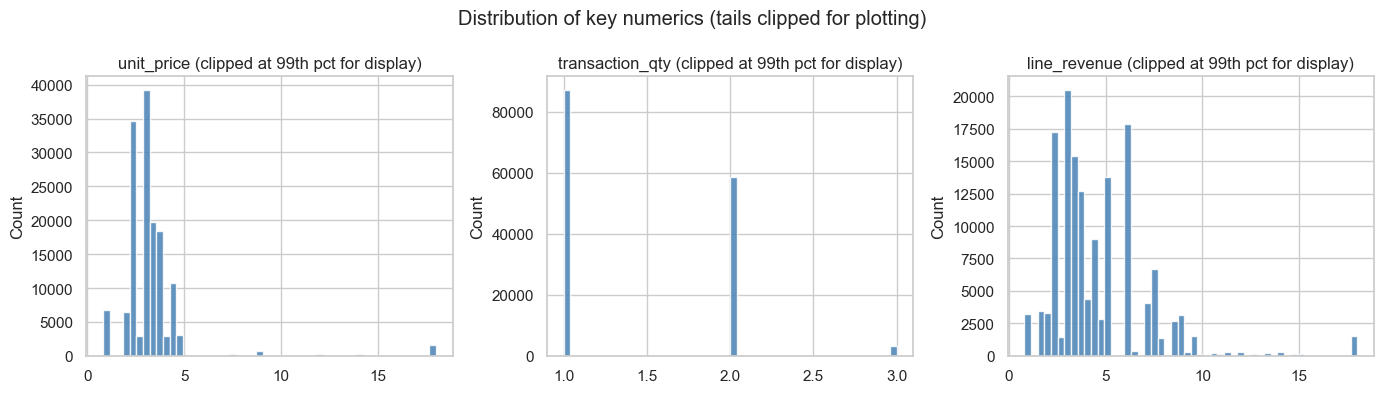

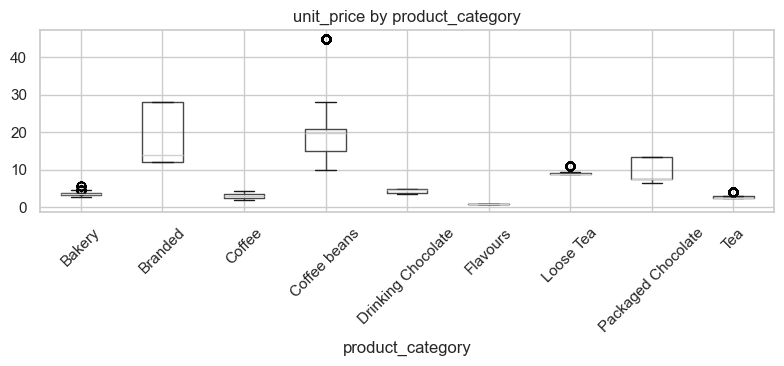

In [13]:
num_cols = ["unit_price", "transaction_qty", "line_revenue"]
print("Numeric summary (with selected percentiles):")
display(df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


def iqr_fences(s: pd.Series, k: float = 1.5) -> tuple[float, float]:
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    return float(q1 - k * iqr), float(q3 + k * iqr)


for col in ["unit_price", "line_revenue"]:
    lo, hi = iqr_fences(df[col])
    mask = (df[col] < lo) | (df[col] > hi)
    print(
        f"{col}: IQR fences [{lo:.4g}, {hi:.4g}] — outside: {mask.sum():,} rows ({100 * mask.mean():.2f}%)"
    )

qty_threshold = max(20.0, float(df["transaction_qty"].quantile(0.995)))
mask_qty = df["transaction_qty"] >= qty_threshold
print(
    f"\ntransaction_qty >= {qty_threshold:.0f} (high-quantity tail): {mask_qty.sum():,} rows"
)
if mask_qty.any():
    display(df.loc[mask_qty, num_cols + ["product_detail", "store_location"]].head(15))

print("\nTop 15 lines by line_revenue (inspect for data quirks):")
display(
    df.nlargest(15, "line_revenue")[
        ["store_location", "product_detail", "transaction_qty", "unit_price", "line_revenue", "date"]
    ]
)

price_by_sku = (
    df.groupby("product_detail", observed=True)["unit_price"]
    .agg(count="count", mean="mean", std="std", min="min", max="max")
    .reset_index()
)
price_by_sku = price_by_sku[price_by_sku["count"] >= 30]
price_by_sku["cv"] = price_by_sku["std"] / price_by_sku["mean"].replace(0, np.nan)
print("\nproduct_detail with highest price CV (min 30 lines) — possible inconsistencies:")
display(price_by_sku.sort_values("cv", ascending=False).head(12))

print("\nLargest basket totals (order_revenue):")
display(
    order_agg.nlargest(12, "order_revenue")[
        ["store_location", "date", "n_lines", "order_qty_total", "order_revenue"]
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols, strict=True):
    cap = df[col].quantile(0.99)
    clipped = df[col].clip(upper=cap)
    clipped.hist(bins=50, ax=ax, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_title(f"{col} (clipped at 99th pct for display)")
    ax.set_ylabel("Count")
fig.suptitle("Distribution of key numerics (tails clipped for plotting)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_outliers_numeric_hist.png", bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 4))
df.boxplot(column="unit_price", by="product_category", ax=ax2, rot=45)
ax2.set_title("unit_price by product_category")
ax2.set_xlabel("product_category")
plt.suptitle("")
fig2.tight_layout()
fig2.savefig(OUTPUTS_DIR / "fig_outliers_price_by_category.png", bbox_inches="tight")
plt.show()


**Conclusion (section 4.5).** The 1.5×IQR flags on pooled `unit_price` and `line_revenue` pick up a few percent of rows because the catalogue mixes **cheap drink lines** with **merchandise** and **premium SKUs** (e.g. Civet Cat at a high unit price). Those tails are **structural** for this business, not evidence of bad rows: the largest `line_revenue` values match **quantity × unit price**, and `transaction_qty` stays in a modest range (no extreme bulk spikes under the rule we used).

We **do not remove** these rows for downstream analysis. **Price CV by `product_detail`** highlights SKUs with several price points (promotions, pack sizes, or tiered pricing); treat that as **documentation**, not a mandate to drop data. If a model is sensitive to heavy tails, prefer **transforms**, **robust scaling**, or **stratification by product type** rather than deleting valid transactions.


---

## Section 5 — Feature engineering (person 2)

After outlier screening (Section 4.5), we extend the cleaned line-level `DataFrame` with **calendar fields**, **US (federal + New York state) holiday** flags from `us_ny_holidays_2023.csv` (aligned with Maven Roasters' NYC-area stores), simple **product tags** for regression or interaction terms, and an **enriched export** for Sections 7–8.

The **first** code cell covers **5.1** extra calendar columns, **5.2** `us_ny_holidays_2023.csv` merge, **5.3** drink / food coarse tags, **5.4** write `outputs/lines_enriched.csv`. **5.5** (following cells) runs **descriptive analysis** on temporal and holiday fields.

**Definitions:** `transaction_dt` is **calendar date** from the file plus **`transaction_time`** (hour-minute-second of the line). **`date`** is that instant normalised to **midnight** for daily joins and holiday matching. **`hour`** / **`dow`** / **`month`** follow `transaction_dt`. **`is_holiday`** is 1 when `date` matches a row in `us_ny_holidays_2023.csv` (filtered to years present in the transactions). **`days_to_next_holiday`** is whole days from that calendar day until the **next** holiday date in the filtered calendar **on or after** that day (0 on a holiday); it is computed once per distinct `date` then mapped (fast and consistent).

**Note:** `date`, `hour`, `dow`, `month`, and `is_weekend` are already created in Section 3; we add week, season, month boundaries, and labels here.


In [14]:
# --- 5.1 Calendar features (beyond Section 3) ---
df["day_name"] = df["date"].dt.day_name()
df["year"] = df["date"].dt.year
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
df["is_month_end"] = df["date"].dt.is_month_end.astype(int)


def season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Spring"
    if m in (6, 7, 8):
        return "Summer"
    return "Autumn"


df["season"] = df["month"].map(season_from_month)

# --- 5.2 Holidays (US federal + NY state — 2023 list, NYC-relevant) ---
HOLIDAYS_PATH = PROJECT_ROOT / "us_ny_holidays_2023.csv"
holidays_cal = pd.read_csv(HOLIDAYS_PATH, parse_dates=["Date"])
holidays_cal = holidays_cal.rename(
    columns={"Date": "date", "Holiday": "holiday", "Type": "holiday_type"}
)
years_in_df = sorted(df["date"].dt.year.unique())
holidays_y = holidays_cal[holidays_cal["date"].dt.year.isin(years_in_df)].copy()
holidays_y["date_norm"] = holidays_y["date"].dt.normalize()
holiday_dates = set(holidays_y["date_norm"].dt.date)
df["is_holiday"] = df["date"].dt.date.isin(holiday_dates).astype(int)

holiday_ts_sorted = sorted(pd.to_datetime(holidays_y["date_norm"].unique()))


def days_to_next_holiday(d, holiday_list):
    d_norm = pd.Timestamp(d).normalize()
    future = [h for h in holiday_list if h >= d_norm]
    if not future:
        return np.nan
    return (future[0] - d_norm).days


# One lookup per distinct calendar date (same result as row-wise apply, much faster)
_date_norm_series = df["date"].dt.normalize()
uniq_norm = sorted(_date_norm_series.unique(), key=lambda x: pd.Timestamp(x))
_days_map = {
    pd.Timestamp(d).normalize(): days_to_next_holiday(d, holiday_ts_sorted) for d in uniq_norm
}
df["days_to_next_holiday"] = _date_norm_series.map(lambda x: _days_map[pd.Timestamp(x).normalize()])

print("Years in transactions:", years_in_df)
print(f"Holiday calendar rows (filtered years): {len(holidays_y)}")
print(f"Lines on holidays: {df['is_holiday'].sum():,}")
print(
    "days_to_next_holiday min–max:",
    df["days_to_next_holiday"].min(),
    "–",
    df["days_to_next_holiday"].max(),
)

# --- 5.3 Product tags (Maven Roasters `product_category`) ---
DRINK_CATEGORIES = {
    "Coffee",
    "Tea",
    "Drinking Chocolate",
    "Loose Tea",
    "Coffee beans",
    "Flavours",
}
FOODISH_CATEGORIES = {"Bakery", "Packaged Chocolate", "Branded"}

df["is_drink"] = df["product_category"].isin(DRINK_CATEGORIES).astype(int)
df["item_category_coarse"] = np.where(
    df["product_category"].isin(FOODISH_CATEGORIES),
    "food_merch",
    np.where(df["is_drink"] == 1, "drinks", "other"),
)

print("\nitem_category_coarse:")
print(df["item_category_coarse"].value_counts())
# --- 5.4 Export enriched line-level table ---
enriched_path = OUTPUTS_DIR / "lines_enriched.csv"
df.to_csv(enriched_path, index=False)
print("\nWrote:", enriched_path, "shape:", df.shape)
display(
    df[
        [
            "date",
            "store_location",
            "is_holiday",
            "days_to_next_holiday",
            "season",
            "item_category_coarse",
        ]
    ].head()
)




Years in transactions: [np.int32(2023)]
Holiday calendar rows (filtered years): 13
Lines on holidays: 3,113
days_to_next_holiday min–max: 0 – 48

item_category_coarse:
item_category_coarse
drinks        125086
food_merch     24030
Name: count, dtype: int64
Hot drink lines: 116,543



Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\semestral_work_DD\outputs\lines_enriched.csv shape: (149116, 33)


,date,store_location,is_holiday,days_to_next_holiday,season,item_category_coarse,is_hot_drink
0,2023-01-01,Lower Manhattan,0,1,Winter,drinks,1
1,2023-01-01,Lower Manhattan,0,1,Winter,drinks,1
2,2023-01-01,Lower Manhattan,0,1,Winter,drinks,1
3,2023-01-01,Lower Manhattan,0,1,Winter,drinks,1
4,2023-01-01,Lower Manhattan,0,1,Winter,drinks,1


### 5.5 Descriptive analysis — temporal and holiday features

Tables and plots below summarise each engineered time and holiday column. **Assumption:** store timestamps are treated as a single timezone (no offset column in the source file).


In [ ]:
# --- 5.5 Descriptive analysis: temporal + holiday + product-tag fields ---
temporal_num = [
    "hour",
    "dow",
    "month",
    "year",
    "week",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "days_to_next_holiday",
    "is_drink",
]
temporal_cat = ["day_name", "season", "item_category_coarse"]
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

print("=== Calendar span (line-level) ===")
print("transaction_dt min / max:", df["transaction_dt"].min(), "->", df["transaction_dt"].max())
print("Distinct calendar dates (date):", df["date"].nunique())
print("Year values in data:", sorted(df["year"].unique().tolist()))

print("\n=== Numeric / binary temporal features — describe ===")
display(df[temporal_num].describe().T)

print("\n=== hour (from transaction_dt) — line counts ===")
display(df["hour"].value_counts().sort_index().to_frame("n_lines"))

print("\n=== day of week (0=Mon) — line counts ===")
vc_dow = df["dow"].value_counts().sort_index()
vc_dow.index = [dow_labels[i] for i in vc_dow.index.astype(int)]
display(vc_dow.to_frame("n_lines"))

print("\n=== month — line counts ===")
display(df["month"].value_counts().sort_index().to_frame("n_lines"))

print("\n=== ISO week — range ===", int(df["week"].min()), "–", int(df["week"].max()))

print("\n=== Categorical labels — value counts ===")
for col in temporal_cat:
    print(f"\n-- {col} --")
    display(df[col].value_counts(dropna=False))

print("\n=== Holiday file rows used for transaction years (head) ===")
display(holidays_y[["date_norm", "holiday", "holiday_type"]].rename(columns={"date_norm": "date"}).head(20))

holiday_lookup = (
    holidays_y.sort_values("date_norm")
    .drop_duplicates(subset=["date_norm"], keep="first")
    .set_index("date_norm")["holiday"]
)
print("\n=== Lines on public holidays — by holiday name ===")
lines_on_h = df.loc[df["is_holiday"] == 1, ["date"]].copy()
lines_on_h["holiday_name"] = lines_on_h["date"].dt.normalize().map(holiday_lookup)
display(lines_on_h["holiday_name"].value_counts())

print("\n=== Calendar days in data that appear in us_ny_holidays_2023.csv ===")
data_days = {pd.Timestamp(d).normalize() for d in df["date"].dt.normalize().unique()}
cal_days = {pd.Timestamp(d).normalize() for d in holiday_lookup.index.unique()}
overlap_days = sorted(data_days & cal_days)
print(len(overlap_days), "days, sample:", [d.strftime("%Y-%m-%d") for d in overlap_days[:12]])

print("\n=== days_to_next_holiday — describe ===")
display(df["days_to_next_holiday"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]))
nan_d = int(df["days_to_next_holiday"].isna().sum())
if nan_d:
    print("NaN rows:", nan_d, "(no holiday on or after that calendar day in filtered file)")

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
df["hour"].hist(bins=range(25), ax=axes[0, 0], color="steelblue", edgecolor="white")
axes[0, 0].set_title("Hour of sale (transaction_dt)")
axes[0, 0].set_xlabel("Hour")
dow_counts = df["dow"].value_counts().sort_index().reindex(range(7), fill_value=0)
dow_counts.index = dow_labels
dow_counts.plot(kind="bar", ax=axes[0, 1], rot=0, color="0.55")
axes[0, 1].set_title("Lines by day of week")
axes[0, 1].set_xlabel("")
df["days_to_next_holiday"].dropna().hist(bins=40, ax=axes[1, 0], color="coral", edgecolor="white")
axes[1, 0].set_title("Days until next listed holiday")
axes[1, 0].set_xlabel("days_to_next_holiday")
df["season"].value_counts().plot(kind="barh", ax=axes[1, 1])
axes[1, 1].set_title("Season (from calendar month)")
fig.suptitle("Temporal and holiday feature distributions")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_descriptive_temporal_features.png", bbox_inches="tight")
plt.show()



---

## Section 6 — EDA visualisations (person 1)

Figures saved under **`outputs/`**, faceted by **`store_location`** where noted.

In [15]:
store_order = [s for s in df["store_location"].unique()]
palette = sns.color_palette("muted", n_colors=len(store_order))
store_palette = dict(zip(store_order, palette, strict=True))

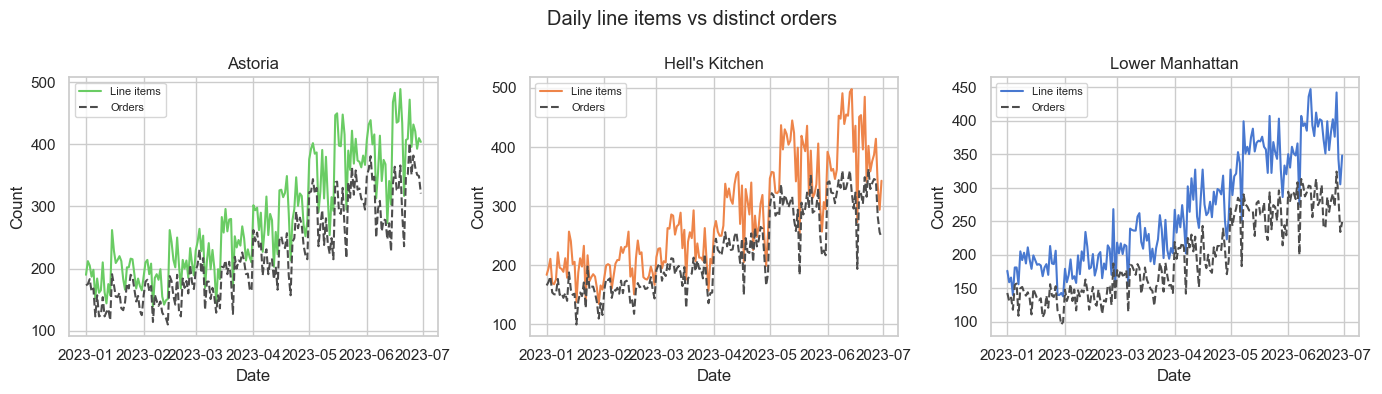

In [16]:
daily_lines = (
    df.groupby(["date", "store_location"], observed=True).size().reset_index(name="n_lines")
)
daily_orders = (
    df.groupby(["date", "store_location"], observed=True)["order_id"]
    .nunique()
    .reset_index(name="n_orders")
)
daily_vol = daily_lines.merge(daily_orders, on=["date", "store_location"])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(daily_vol["store_location"].unique()), strict=True):
    sub = daily_vol[daily_vol["store_location"] == store].sort_values("date")
    ax.plot(sub["date"], sub["n_lines"], label="Line items", color=store_palette[store])
    ax.plot(sub["date"], sub["n_orders"], label="Orders", linestyle="--", color="0.3")
    ax.set_title(store)
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)
fig.suptitle("Daily line items vs distinct orders")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_daily_lines_vs_orders.png", bbox_inches="tight")
plt.show()

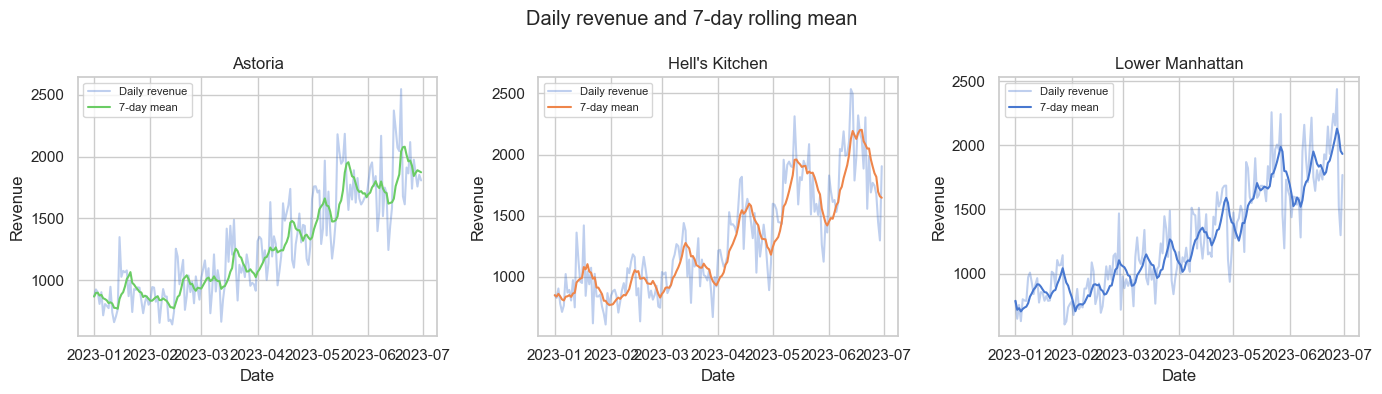

In [17]:
daily_rev = (
    df.groupby(["date", "store_location"], observed=True)["line_revenue"]
    .sum()
    .reset_index()
    .sort_values(["store_location", "date"])
)
daily_rev["rev_7d"] = daily_rev.groupby("store_location", observed=True)["line_revenue"].transform(
    lambda s: s.rolling(7, min_periods=1).mean()
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(daily_rev["store_location"].unique()), strict=True):
    sub = daily_rev[daily_rev["store_location"] == store]
    ax.plot(sub["date"], sub["line_revenue"], alpha=0.35, label="Daily revenue")
    ax.plot(sub["date"], sub["rev_7d"], label="7-day mean", color=store_palette[store])
    ax.set_title(store)
    ax.set_xlabel("Date")
    ax.set_ylabel("Revenue")
    ax.legend(fontsize=8)
fig.suptitle("Daily revenue and 7-day rolling mean")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_daily_revenue_rolling.png", bbox_inches="tight")
plt.show()

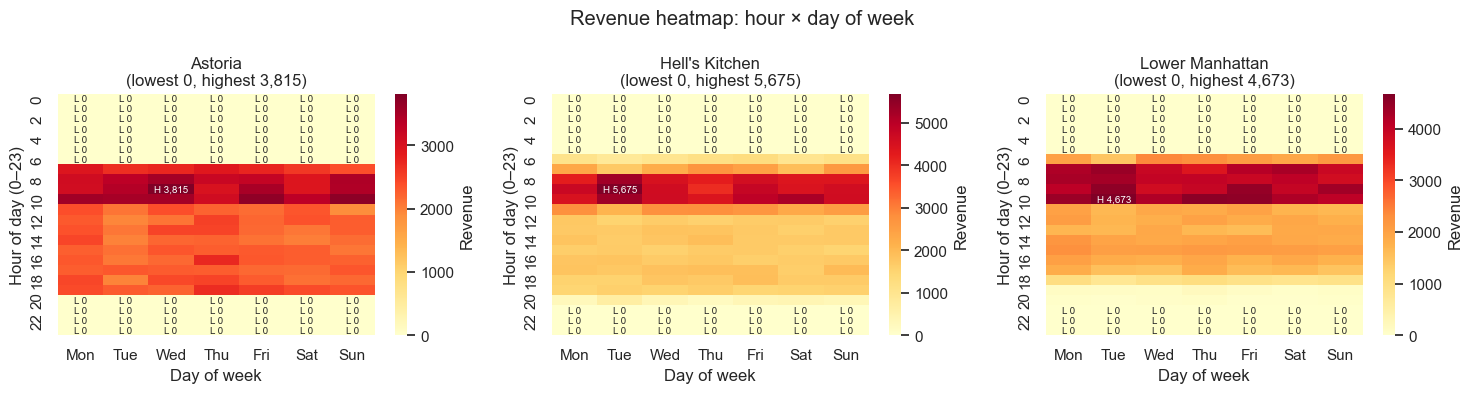

In [18]:
heat = (
    df.groupby(["store_location", "dow", "hour"], observed=True)["line_revenue"]
    .sum()
    .reset_index()
)
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, store in zip(axes, sorted(heat["store_location"].unique()), strict=True):
    sub = heat[heat["store_location"] == store]
    pivot = sub.pivot(index="hour", columns="dow", values="line_revenue").reindex(
        columns=range(7), fill_value=0
    )
    pivot = pivot.reindex(range(24), fill_value=0)
    pivot.columns = dow_labels
    sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Revenue"})
    ax.set_title(store)
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Hour of day (0–23)")
fig.suptitle("Revenue heatmap: hour × day of week")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_heatmap_hour_dow.png", bbox_inches="tight")
plt.show()


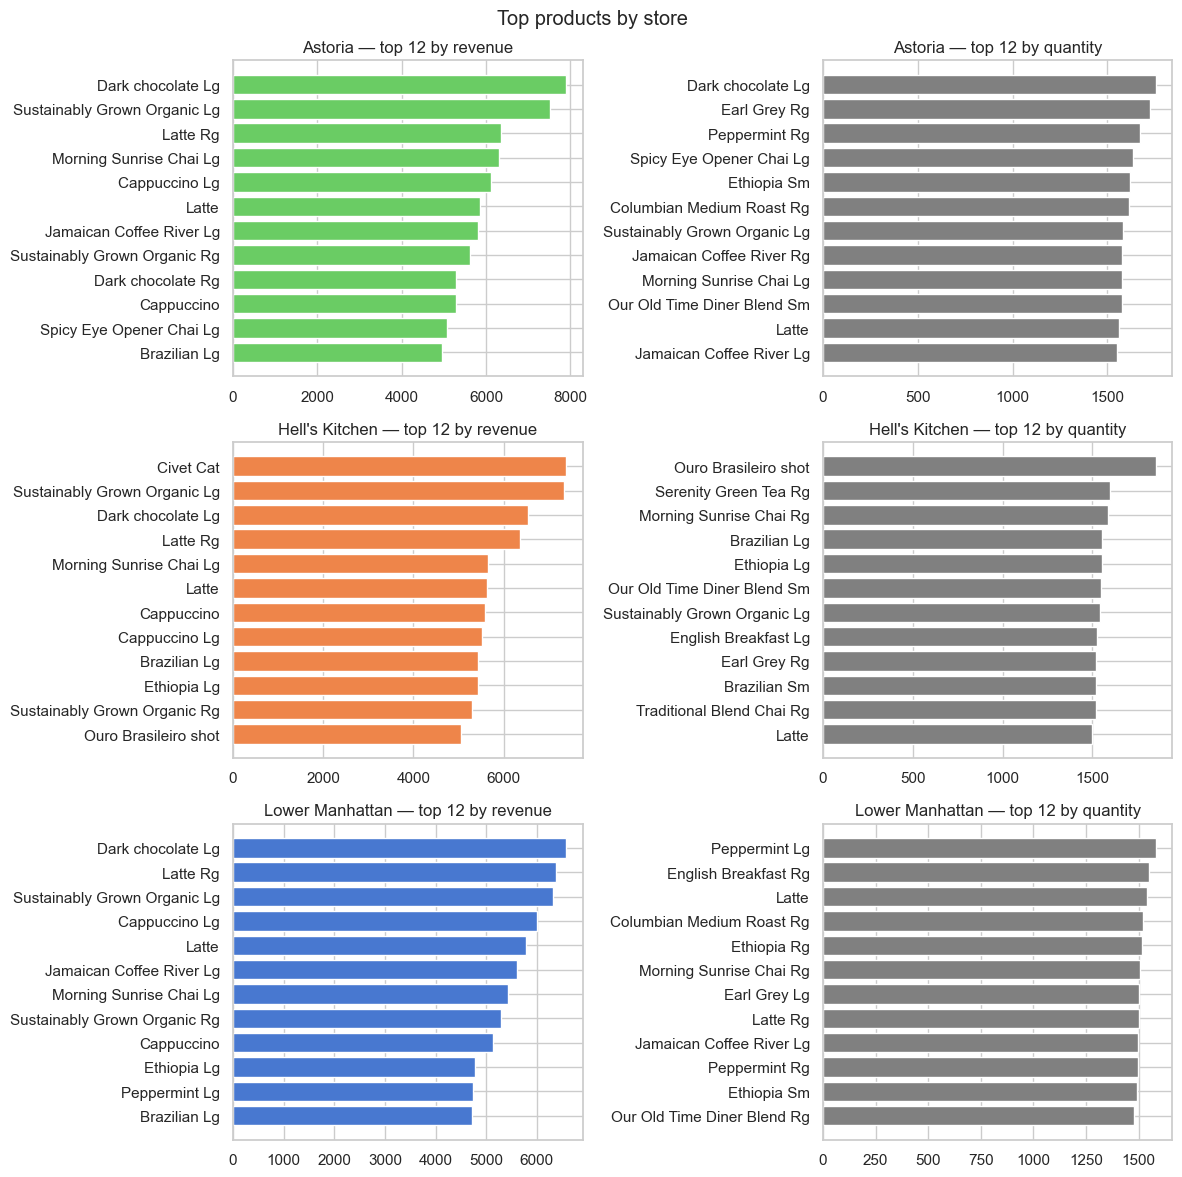

In [19]:
N_TOP = 12
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
for i, store in enumerate(sorted(df["store_location"].unique())):
    sub = df[df["store_location"] == store]
    top_rev = (
        sub.groupby("product_detail", observed=True)["line_revenue"]
        .sum()
        .nlargest(N_TOP)
        .iloc[::-1]
    )
    top_qty = (
        sub.groupby("product_detail", observed=True)["transaction_qty"]
        .sum()
        .nlargest(N_TOP)
        .iloc[::-1]
    )
    axes[i, 0].barh(top_rev.index.astype(str), top_rev.values, color=store_palette[store])
    axes[i, 0].set_title(f"{store} — top {N_TOP} by revenue")
    axes[i, 1].barh(top_qty.index.astype(str), top_qty.values, color="0.5")
    axes[i, 1].set_title(f"{store} — top {N_TOP} by quantity")
fig.suptitle("Top products by store")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_top_products_rev_qty.png", bbox_inches="tight")
plt.show()

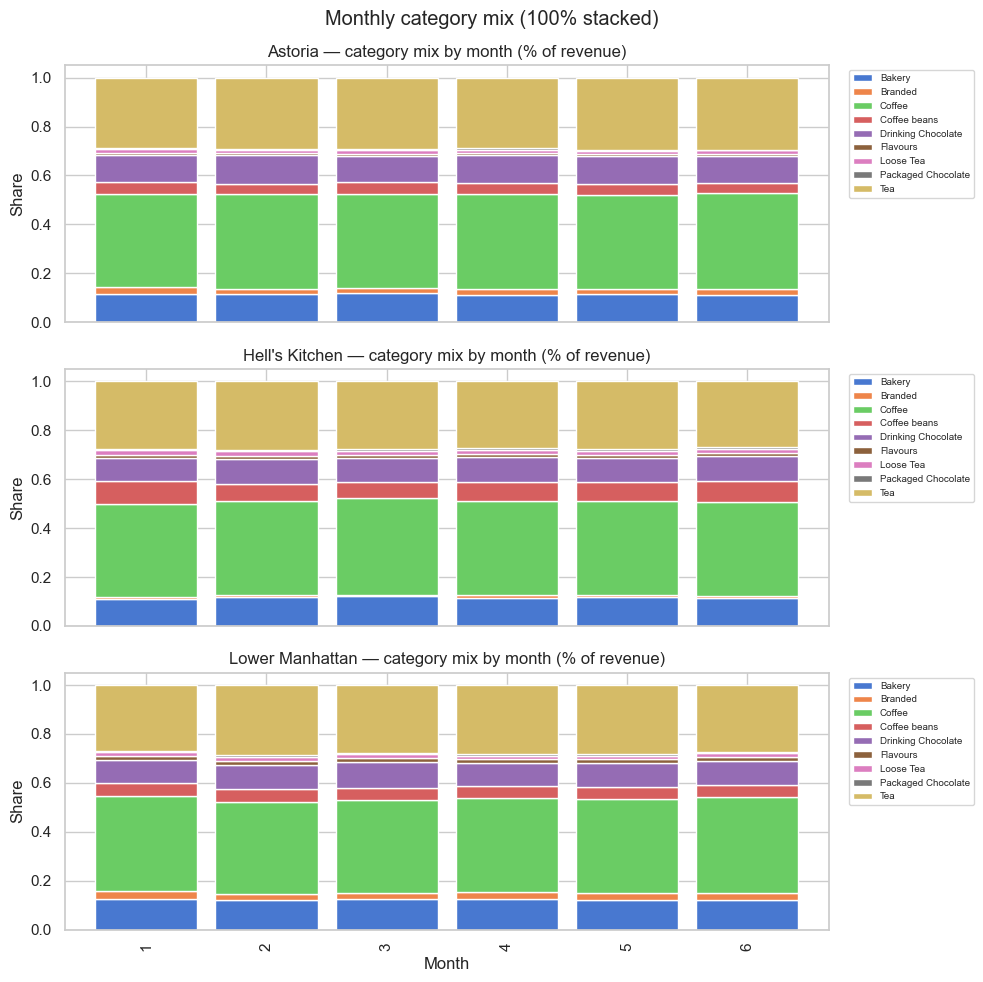

In [20]:
mix = (
    df.groupby(["store_location", "month", "product_category"], observed=True)["line_revenue"]
    .sum()
    .reset_index()
)
mix_pivot = mix.pivot_table(
    index=["store_location", "month"],
    columns="product_category",
    values="line_revenue",
    fill_value=0,
)
mix_pct = mix_pivot.div(mix_pivot.sum(axis=1), axis=0)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
for ax, store in zip(axes, sorted(mix_pct.index.get_level_values(0).unique()), strict=True):
    sub = mix_pct.xs(store, level=0)
    sub.plot(kind="bar", stacked=True, ax=ax, width=0.85, legend=(store == sorted(mix_pct.index.get_level_values(0).unique())[0]))
    ax.set_title(f"{store} — category mix by month (% of revenue)")
    ax.set_ylabel("Share")
    ax.set_xlabel("Month")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
fig.suptitle("Monthly category mix (100% stacked)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_category_mix_month.png", bbox_inches="tight")
plt.show()

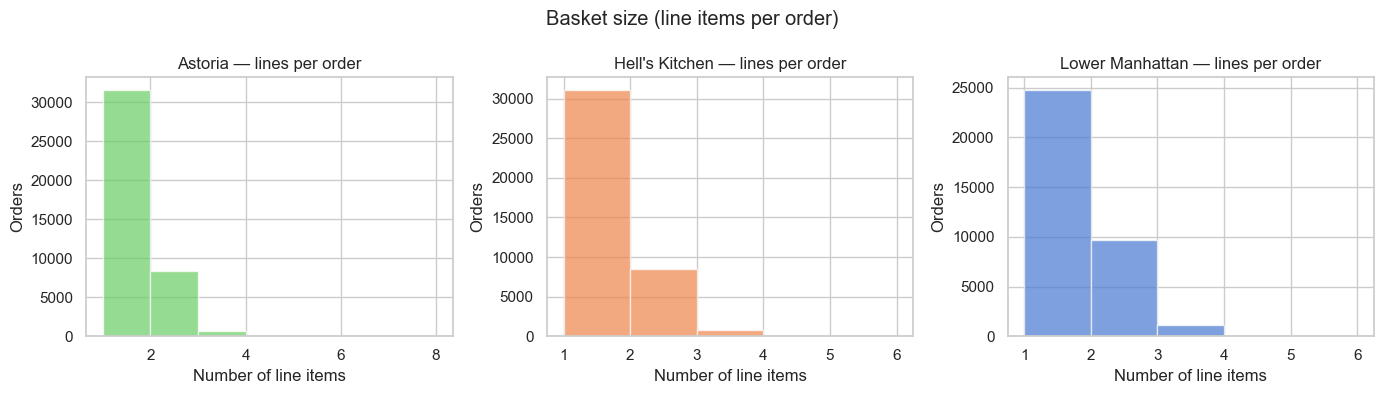

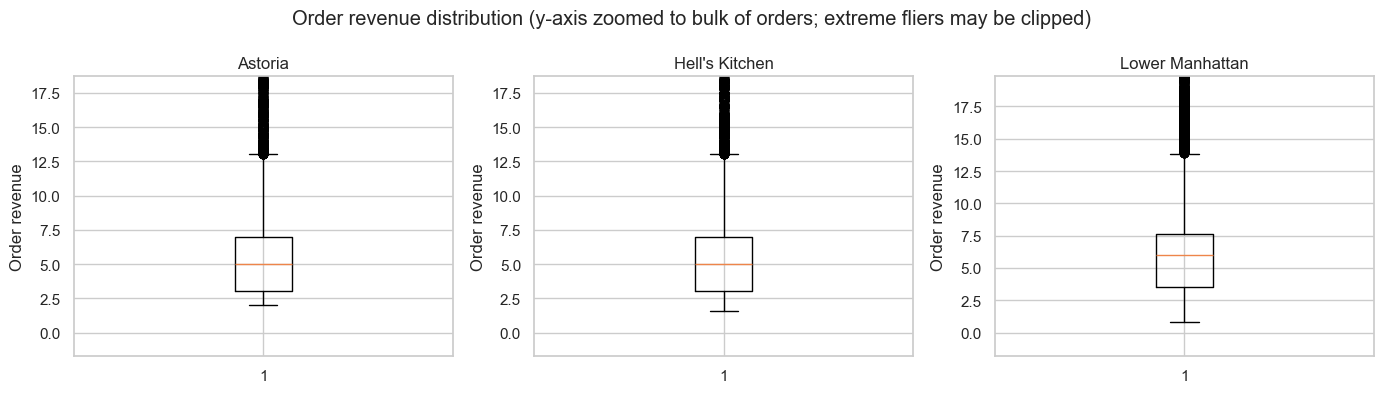

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(order_agg["store_location"].unique()), strict=True):
    sub = order_agg[order_agg["store_location"] == store]
    ax.hist(sub["n_lines"], bins=range(1, int(sub["n_lines"].max()) + 2), alpha=0.7, color=store_palette[store])
    ax.set_title(f"{store} — lines per order")
    ax.set_xlabel("Number of line items")
    ax.set_ylabel("Orders")
fig.suptitle("Basket size (line items per order)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_basket_size_lines.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(order_agg["store_location"].unique()), strict=True):
    sub = order_agg[order_agg["store_location"] == store]
    s = sub["order_revenue"].dropna()
    ax.boxplot(s.to_numpy(), vert=True, showfliers=True)
    ax.set_title(store)
    ax.set_ylabel("Order revenue")
fig.suptitle("Order revenue distribution")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_order_revenue_box.png", bbox_inches="tight")
plt.show()


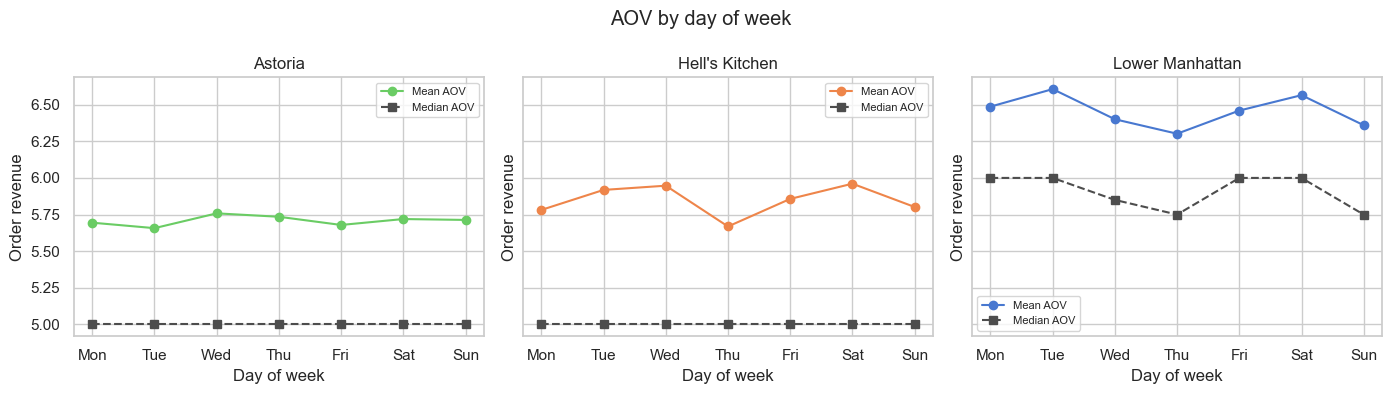

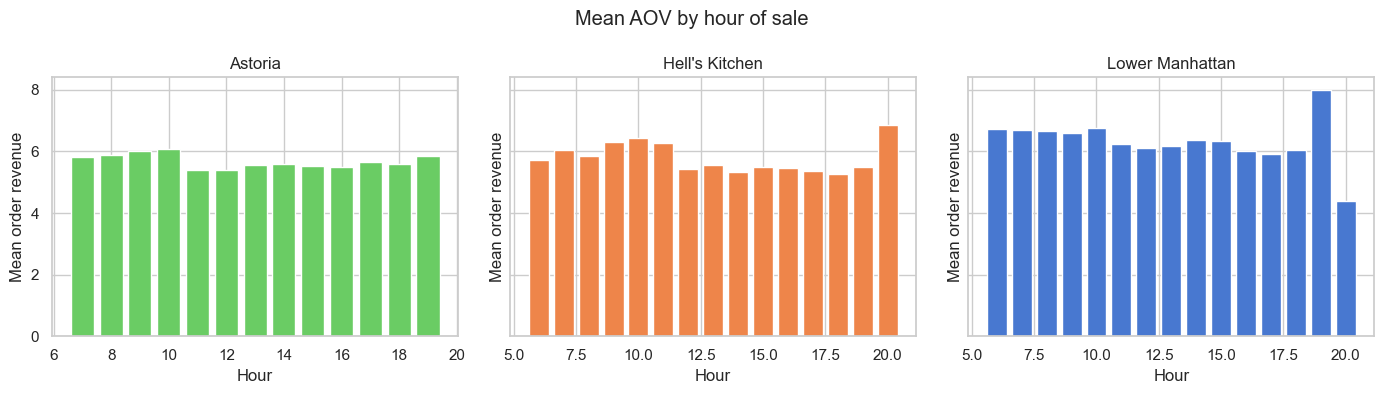

In [22]:
order_agg["dow"] = pd.to_datetime(order_agg["date"]).dt.dayofweek
aov_dow = order_agg.groupby(["store_location", "dow"], observed=True)["order_revenue"].agg(
    mean_aov="mean", median_aov="median"
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
for ax, store in zip(axes, sorted(aov_dow["store_location"].unique()), strict=True):
    sub = aov_dow[aov_dow["store_location"] == store]
    x = sub["dow"]
    ax.plot(x, sub["mean_aov"], marker="o", label="Mean AOV", color=store_palette[store])
    ax.plot(x, sub["median_aov"], marker="s", linestyle="--", label="Median AOV", color="0.3")
    ax.set_xticks(range(7))
    ax.set_xticklabels(dow_labels)
    ax.set_title(store)
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Order revenue")
    ax.legend(fontsize=8)
fig.suptitle("AOV by day of week")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_aov_by_dow.png", bbox_inches="tight")
plt.show()

df_orders = df.drop_duplicates(subset=["order_id"])[["order_id", "store_location", "hour"]].merge(
    order_agg[["order_id", "order_revenue"]], on="order_id", how="inner"
)
aov_hour = df_orders.groupby(["store_location", "hour"], observed=True)["order_revenue"].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, store in zip(axes, sorted(aov_hour["store_location"].unique()), strict=True):
    sub = aov_hour[aov_hour["store_location"] == store].sort_values("hour")
    ax.bar(sub["hour"], sub["order_revenue"], color=store_palette[store], width=0.8)
    ax.set_title(store)
    ax.set_xlabel("Hour")
    ax.set_ylabel("Mean order revenue")
fig.suptitle("Mean AOV by hour of sale")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_aov_by_hour.png", bbox_inches="tight")
plt.show()

---

## Section 7 — Aggregation and correlation (person 2)

- **Daily demand (units)** per `product_detail` and per `product_id`, split by `store_location`; exported for forecasting and stocking (CSV under `outputs/`).
- **Orders vs line items:** for each store × day, compare distinct `order_id` counts to row counts, report **lines per order** and Pearson correlation (nearly collinear at daily level, but slope and residual spread matter).
- **Correlation heatmap** over numeric and calendar fields (and store id) at **line level** to highlight multicollinearity before regression or ML; strongest pairs are tabulated.


Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\semestral_work_DD\outputs\daily_demand_product_detail.csv rows: 31,764
Wrote: C:\Users\jachy\Desktop\Vysoká\2025-erasmus\Classes\Data-driven models\semestral_work_DD\outputs\daily_demand_product_id.csv rows: 31,764
Top mean daily units by store (first 8 SKUs per store):


,store_location,product_detail,mean_daily_qty
20,Astoria,Dark chocolate Lg,9.804469
24,Astoria,Earl Grey Rg,9.636872
63,Astoria,Peppermint Rg,9.346369
15,Astoria,Columbian Medium Roast Rg,9.164773
70,Astoria,Spicy Eye Opener Chai Lg,9.128492
33,Astoria,Ethiopia Sm,9.044693
44,Astoria,Jamaican Coffee River Rg,8.909605
60,Astoria,Our Old Time Diner Blend Sm,8.898305
140,Hell's Kitchen,Ouro Brasileiro shot,10.655172
148,Hell's Kitchen,Serenity Green Tea Rg,8.944134


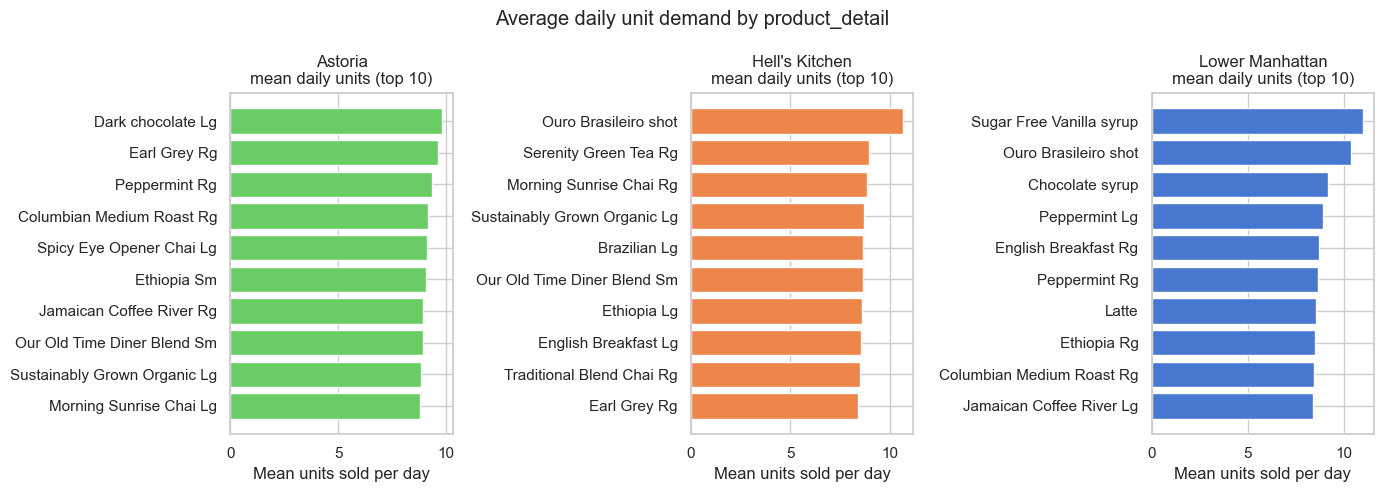

In [23]:
# --- 7.1 Daily unit demand by store × SKU ---
daily_demand_detail = (
    df.groupby(["date", "store_location", "product_detail"], observed=True)["transaction_qty"]
    .sum()
    .reset_index(name="daily_qty")
)
daily_demand_pid = (
    df.groupby(["date", "store_location", "product_id"], observed=True)["transaction_qty"]
    .sum()
    .reset_index(name="daily_qty")
)

demand_detail_path = OUTPUTS_DIR / "daily_demand_product_detail.csv"
demand_pid_path = OUTPUTS_DIR / "daily_demand_product_id.csv"
daily_demand_detail.to_csv(demand_detail_path, index=False)
daily_demand_pid.to_csv(demand_pid_path, index=False)
print("Wrote:", demand_detail_path, "rows:", f"{len(daily_demand_detail):,}")
print("Wrote:", demand_pid_path, "rows:", f"{len(daily_demand_pid):,}")

mean_daily_by_sku = (
    daily_demand_detail.groupby(["store_location", "product_detail"], observed=True)["daily_qty"]
    .mean()
    .reset_index(name="mean_daily_qty")
    .sort_values(["store_location", "mean_daily_qty"], ascending=[True, False])
)
print("Top mean daily units by store (first 8 SKUs per store):")
display(mean_daily_by_sku.groupby("store_location", observed=True).head(8))

N_TOP_DEMAND = 10
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
for ax, store in zip(axes, sorted(mean_daily_by_sku["store_location"].unique()), strict=True):
    sub = mean_daily_by_sku[mean_daily_by_sku["store_location"] == store].head(N_TOP_DEMAND).iloc[::-1]
    ax.barh(sub["product_detail"].astype(str), sub["mean_daily_qty"], color=store_palette[store])
    ax.set_title(f"{store}\nmean daily units (top {N_TOP_DEMAND})")
    ax.set_xlabel("Mean units sold per day")
fig.suptitle("Average daily unit demand by product_detail")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_mean_daily_demand_top_sku.png", bbox_inches="tight")
plt.show()


Lines per order (daily ratio) — summary:


count    543.000000
mean       1.283466
std        0.118727
min        1.068966
25%        1.174102
50%        1.311538
75%        1.364321
max        1.612613
Name: lines_per_order, dtype: float64

Astoria: Pearson r(n_orders, n_lines) = 0.9672
Hell's Kitchen: Pearson r(n_orders, n_lines) = 0.9466
Lower Manhattan: Pearson r(n_orders, n_lines) = 0.9705


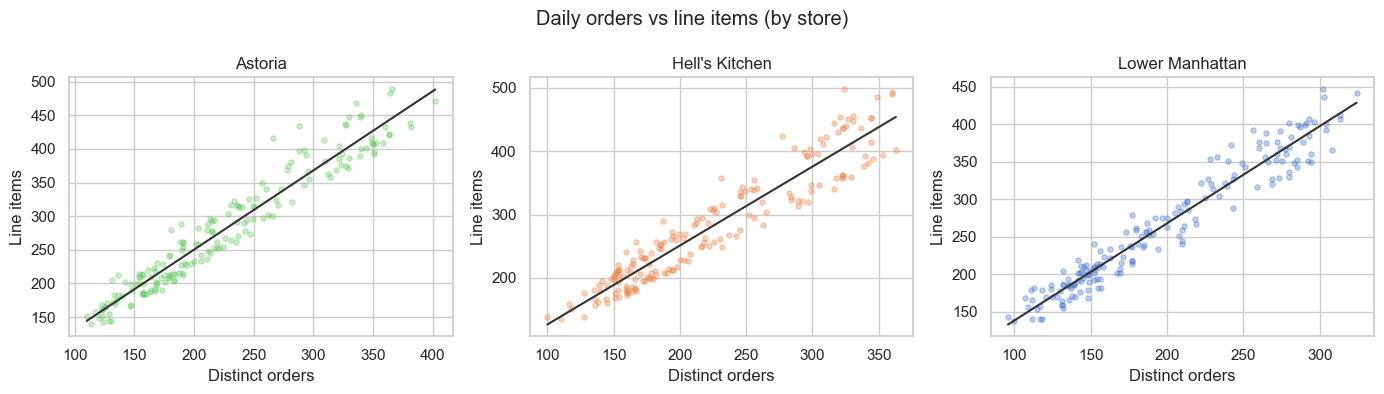

In [24]:
# --- 7.2 Daily order count vs line count (per store × day) ---
daily_lines = (
    df.groupby(["date", "store_location"], observed=True).size().reset_index(name="n_lines")
)
daily_orders = (
    df.groupby(["date", "store_location"], observed=True)["order_id"]
    .nunique()
    .reset_index(name="n_orders")
)
daily_vol = daily_lines.merge(daily_orders, on=["date", "store_location"])
daily_vol["lines_per_order"] = daily_vol["n_lines"] / daily_vol["n_orders"]

print("Lines per order (daily ratio) — summary:")
display(daily_vol["lines_per_order"].describe())

for store in sorted(daily_vol["store_location"].unique()):
    sub = daily_vol[daily_vol["store_location"] == store]
    r = sub["n_orders"].corr(sub["n_lines"])
    print(f"{store}: Pearson r(n_orders, n_lines) = {r:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, store in zip(axes, sorted(daily_vol["store_location"].unique()), strict=True):
    sub = daily_vol[daily_vol["store_location"] == store]
    ax.scatter(sub["n_orders"], sub["n_lines"], alpha=0.35, s=14, color=store_palette[store])
    z = np.polyfit(sub["n_orders"].to_numpy(), sub["n_lines"].to_numpy(), 1)
    x_line = np.linspace(sub["n_orders"].min(), sub["n_orders"].max(), 50)
    ax.plot(x_line, np.poly1d(z)(x_line), color="0.2", lw=1.5)
    ax.set_title(store)
    ax.set_xlabel("Distinct orders")
    ax.set_ylabel("Line items")
fig.suptitle("Daily orders vs line items (by store)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_orders_vs_lines_scatter.png", bbox_inches="tight")
plt.show()


Dropping constant columns for correlation: ['year']


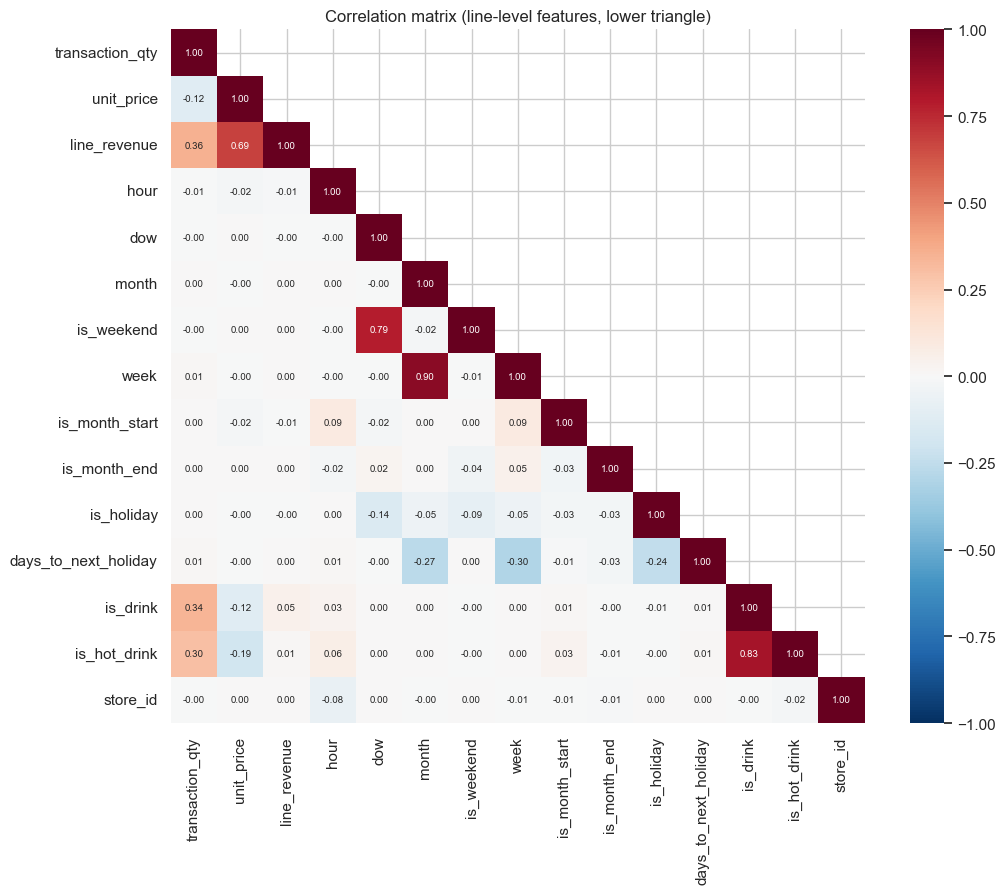

Top 15 pairs by |r|:


,feature_a,feature_b,r,abs_r
26,week,month,0.904764,0.904764
90,is_hot_drink,is_drink,0.829062,0.829062
19,is_weekend,dow,0.786618,0.786618
2,line_revenue,unit_price,0.685550,0.685550
1,line_revenue,transaction_qty,0.356231,0.356231
66,is_drink,transaction_qty,0.339063,0.339063
62,days_to_next_holiday,week,-0.303761,0.303761
78,is_hot_drink,transaction_qty,0.300160,0.300160
60,days_to_next_holiday,month,-0.268514,0.268514
65,days_to_next_holiday,is_holiday,-0.243969,0.243969


In [25]:
# --- 7.3 Correlation matrix: numeric and calendar features (line level) ---
corr_cols = [
    "transaction_qty",
    "unit_price",
    "line_revenue",
    "hour",
    "dow",
    "month",
    "is_weekend",
    "year",
    "week",
    "is_month_start",
    "is_month_end",
    "is_holiday",
    "days_to_next_holiday",
    "is_drink",
    "store_id",
]
corr_df = df[corr_cols].copy()
nunique = corr_df.nunique()
const_cols = nunique[nunique <= 1].index.tolist()
if const_cols:
    print("Dropping constant columns for correlation:", const_cols)
    corr_df = corr_df.drop(columns=const_cols)

corr_mat = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Correlation matrix (line-level features, lower triangle)")
fig.tight_layout()
fig.savefig(OUTPUTS_DIR / "fig_correlation_features.png", bbox_inches="tight")
plt.show()

pairs = (
    corr_mat.where(np.tril(np.ones_like(corr_mat, dtype=bool), k=-1))
    .stack()
    .reset_index()
)
pairs.columns = ["feature_a", "feature_b", "r"]
pairs["abs_r"] = pairs["r"].abs()
print("Top 15 pairs by |r|:")
display(pairs.sort_values("abs_r", ascending=False).head(15))


---

## Section 8 — Forecasting (person 3)

- Weekly or daily series **per store × SKU or category**; train/test split in time; RMSE/MAE.

*Stub — align with `semestral_project_1` / `semestral_project_2` time series cells.*

---

## Section 9 — Optimisation — Gurobi (person 4)

- Decision: units to prepare; objective: expected profit minus **waste cost** with **unsold loss = `unit_cogs` × leftover**.
- Constraints: capacity, budget, service level **per store**.

*Stub.*

---

## Section 10 — Sensitivity and conclusion (person 5)

- Vary demand forecast error, margin assumption, safety stock.
- Compile figures for the report appendix.

*Stub.*